,customer_city,customer_state,total_orders
0,sao paulo,SP,15045
1,rio de janeiro,RJ,6601
2,belo horizonte,MG,2697
3,brasilia,DF,2071
4,curitiba,PR,1489
5,campinas,SP,1406
6,porto alegre,RS,1342
7,salvador,BA,1188
8,guarulhos,SP,1144
9,sao bernardo do campo,SP,911


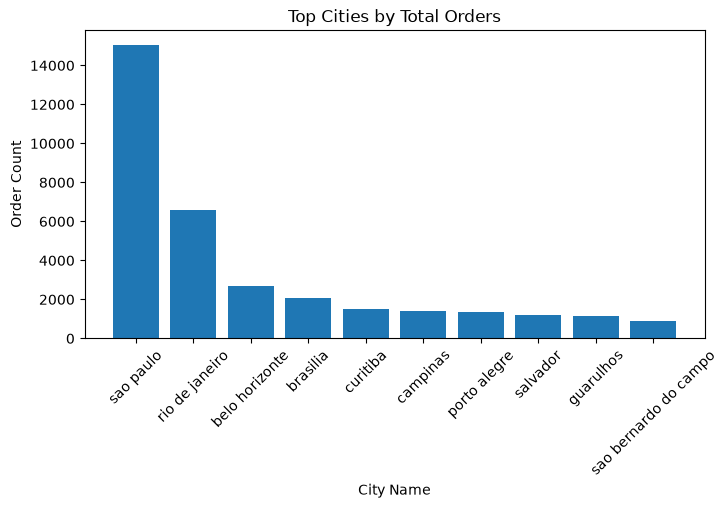

In [1]:
import matplotlib.pyplot as plt
import duckdb

# Sample question before analysis: What cities are placing the most delivered orders?

query = """
SELECT
    c.customer_city,
    c.customer_state,
    COUNT(o.order_id) AS total_orders
FROM 'data/raw/olist_orders_dataset.csv' AS o
JOIN 'data/raw/olist_customers_dataset.csv' AS c
    ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_city, c.customer_state
ORDER By total_orders DESC
LIMIT 10;

"""
top_cities = duckdb.query(query).df()
display(top_cities)


# 1. Prepare the canvas (width, height in inches)
plt.figure(figsize=(8, 4))

# 2. Draw the shape (pass X data, then Y data)
plt.bar(top_cities['customer_city'], top_cities['total_orders'])

# 3. Add human labels
plt.title('Top Cities by Total Orders')
plt.xlabel('City Name')
plt.ylabel('Order Count')

# 4. Optional: Clean up layout (rotate labels, add gridlines)
plt.xticks(rotation=45)

# 5. Render the image on screen
plt.show()

In [ ]:
#Different charts:
#plt.plot() Line chart
#plt.bar() or plt.barh()
#plt.hist()
#plt.scatter()